In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [56]:
# Helper function to display images
def display_images(images, titles, cmap='gray'):
    plt.figure(figsize=(12, 4))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis('off')
    plt.show()

### Read `CoffeeBeans.tif` and threshold it

In [8]:
img = cv2.imread('CoffeeBeans.tif')
img.shape
print("Image shape:", img.shape, "min/max:", img.min(), img.max())

Image shape: (296, 301, 3) min/max: 0 231


In [26]:
# Convert to grayscale (I was getting the error "'src_type' is 64 (CV_8UC3)")
if img.ndim == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [28]:
# Convert to 8-bit before applying Otsu

img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) if (img.dtype != np.uint8) else img

# if img.dtype != np.uint8:
#     img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [31]:
# Otsu with 0 threshold
threshold_value, binary = cv2.threshold(
    img_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
print("Otsu threshold: ", threshold_value)
print("Binary: ", binary)

Otsu threshold:  71.0
Binary:  [[  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]]


In [32]:
if np.mean(binary) > 127:
    True

Text(0.5, 1.0, 'Original Image')

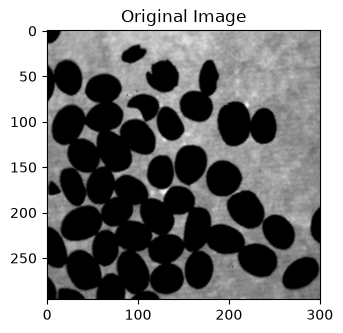

In [43]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_8bit, cmap='gray')
plt.title("Original Image")

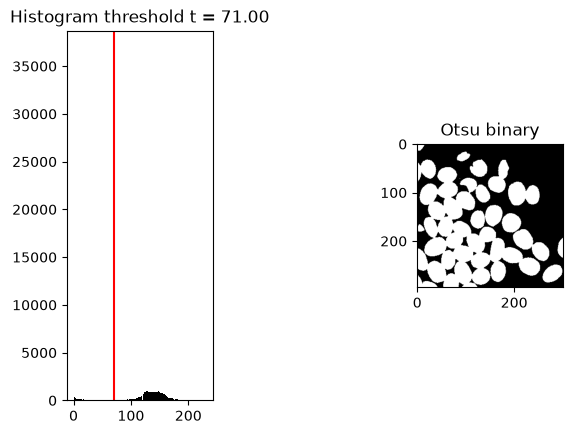

In [55]:
plt.subplot(1,3, 1)
plt.hist(img_8bit.ravel(), bins=256, color='k')
plt.title('Histogram threshold t = {:.2f}'.format(threshold_value))
plt.axvline(threshold_value, color='r')

t, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Beans should be WHITE (foreground). If they're black, invert.
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

plt.subplot(1,3,3);
plt.imshow(binary, cmap='gray'); 
plt.title("Otsu binary"); 


 #### Segment and label each coffee bean

Here is my approach -
```text
Raw image
   ↓
1. Grayscale + Otsu (binary mask) ➡ done above
   ↓
2. Morphological cleanup (remove specks, fill holes)
   ↓
3. Separate touching beans:
      Distance transform → local maxima → watershed
   ↓
4. Label each bean (connected components)
   ↓
5. Filter tiny regions, measure area/centroid, overlay
```

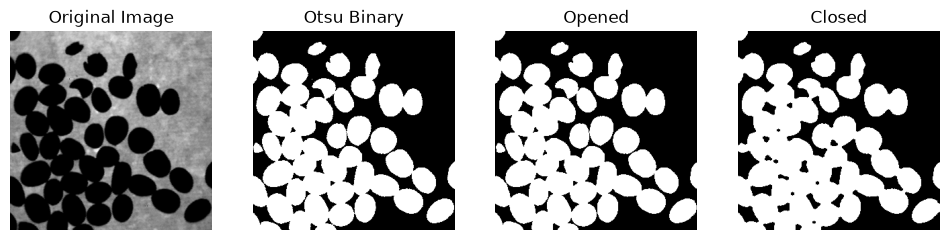

In [60]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

display_images([img_8bit, binary, opened, closed],
               ["Original Image", "Otsu Binary", "Opened", "Closed"])

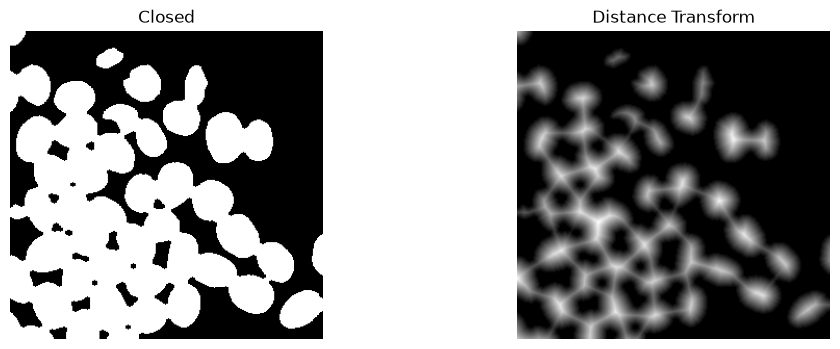

In [61]:
# Distance transform
dist_transform = cv2.distanceTransform(closed, cv2.DIST_L2, 5)
dist_transform = cv2.normalize(
    dist_transform, None, 0, 1.0, cv2.NORM_MINMAX).astype(np.float32)
display_images([closed, dist_transform], ["Closed", "Distance Transform"])
